# Atividade 3 — Classificador com CNN Pré-treinada

Este notebook implementa um baseline de **transfer learning por feature extraction** para o dataset [Images Dataset](https://www.kaggle.com/datasets/pavansanagapati/images-dataset).

A ResNet-50 pré-treinada no ImageNet será usada como backbone. Todas as camadas convolucionais permanecerão congeladas; somente a nova camada linear de classificação será treinada. O baseline não utiliza data augmentation, para que as propostas de melhoria possam ser avaliadas a partir de uma referência limpa.

## 1. Configuração do ambiente

No Colab, selecione **Runtime > Change runtime type > T4 GPU** (ou outra GPU disponível). Se o dataset ainda não estiver em `/content/images-dataset`, faça o download pelo Kaggle e ajuste `DATASET_DIR` na célula seguinte.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from tqdm.auto import tqdm

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
NUM_WORKERS = 2
DATASET_DIR = '/content/images-dataset'  # ajuste se necessário

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('GPU não disponível; o notebook executará em CPU.')

Device: cuda
GPU: Tesla T4


### Download do dataset no Colab

A célula abaixo baixa o dataset automaticamente via API do Kaggle. As credenciais são lidas dos Secrets do Colab (`KAGGLE_USERNAME` e `KAGGLE_KEY`). Se o download já tiver sido feito, ele é dispensado. Sem credenciais, faça upload manual do arquivo `.zip` do dataset para `/content/` e execute a célula novamente.

In [4]:
import zipfile

# Configuração automática das credenciais da API Kaggle no Google Colab
try:
    from google.colab import userdata
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    print('Credenciais do Kaggle carregadas dos Secrets do Colab.')
except Exception:
    pass

# Instala a CLI do Kaggle se necessário
!pip install kaggle --quiet

KAGGLE_DATASET_SLUG = 'pavansanagapati/images-dataset'
TARGET_DIR = Path(DATASET_DIR)
TARGET_DIR.mkdir(parents=True, exist_ok=True)

DOWNLOAD_IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp', '.tif', '.tiff'}

# Verifica se o diretório já possui imagens extraídas
existing_images = [f for f in TARGET_DIR.rglob('*') if f.is_file() and f.suffix.lower() in DOWNLOAD_IMAGE_EXTENSIONS]

if not existing_images:
    print(f"Baixando dataset '{KAGGLE_DATASET_SLUG}' do Kaggle...")
    !kaggle datasets download -d {KAGGLE_DATASET_SLUG} -p /content --force

    # Procura arquivos zip em /content
    zip_candidates = list(Path('/content').glob('*images-dataset*.zip')) + list(Path('/content').glob('*.zip'))

    if zip_candidates:
        zip_to_extract = zip_candidates[0]
        print(f"Extraindo '{zip_to_extract}' para '{TARGET_DIR}'...")
        with zipfile.ZipFile(zip_to_extract, 'r') as zip_ref:
            zip_ref.extractall(TARGET_DIR)
        print('Extração concluída!')
    else:
        print('Aviso: Nenhum arquivo zip encontrado em /content/. Se você não possui API Key do Kaggle, '
              'faça upload manual do arquivo zip do dataset para /content/ e execute esta célula novamente.')
else:
    print(f"Dataset já presente em '{TARGET_DIR}' ({len(existing_images)} imagens encontradas). Download dispensado.")


Baixando dataset 'pavansanagapati/images-dataset' do Kaggle...
Dataset URL: https://www.kaggle.com/datasets/pavansanagapati/images-dataset
License(s): CC0-1.0
100% 1.01G/1.01G [00:07<00:00, 149MB/s] 

Extraindo '/content/images-dataset.zip' para '/content/images-dataset'...
Extração concluída!


## 2. Inspeção, validação e construção do DataFrame

As classes são inferidas automaticamente pelo nome do diretório pai de cada imagem. Assim, a célula funciona mesmo quando o dataset possui uma pasta intermediária adicional. Imagens que não podem ser abertas são excluídas antes da divisão treino/validação.

In [5]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp', '.tif', '.tiff'}
dataset_path = Path(DATASET_DIR)
if not dataset_path.exists():
    raise FileNotFoundError(f'Dataset não encontrado em: {dataset_path}')

image_paths = sorted([p for p in dataset_path.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS])
if not image_paths:
    raise RuntimeError('Nenhuma imagem encontrada. Verifique DATASET_DIR e a estrutura do dataset.')

records = []
for path in image_paths:
    try:
        with Image.open(path) as image:
            image.verify()
        records.append({'image_path': str(path), 'class_name': path.parent.name})
    except (UnidentifiedImageError, OSError, ValueError) as error:
        print(f'Imagem inválida removida: {path} ({error})')

df = pd.DataFrame(records)
if df.empty:
    raise RuntimeError('Nenhuma imagem válida restou após a validação.')
class_names = sorted(df['class_name'].unique())
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
df['label'] = df['class_name'].map(class_to_idx).astype(int)
df = df[['image_path', 'label', 'class_name']].sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Imagens encontradas: {len(image_paths)}')
print(f'Imagens válidas: {len(df)}')
print(f'Imagens removidas: {len(image_paths) - len(df)}')
print(f'Número de classes: {len(class_names)}')
print(f'Classes: {class_names}')
print(f'Extensões: {sorted({Path(p).suffix.lower() for p in df.image_path})}')
display(df.head())
display(df['class_name'].value_counts().rename('count').to_frame())

Imagens encontradas: 3606
Imagens válidas: 3606
Imagens removidas: 0
Número de classes: 7
Classes: ['bike', 'cars', 'cats', 'dogs', 'flowers', 'horses', 'human']
Extensões: ['.bmp', '.jpg', '.png']


,image_path,label,class_name
0,/content/images-dataset/data/horses/horse-36.jpg,5,horses
1,/content/images-dataset/data/data/bike/bike_01...,0,bike
2,/content/images-dataset/data/data/dogs/dog.34.jpg,3,dogs
3,/content/images-dataset/data/flowers/0152.png,4,flowers
4,/content/images-dataset/data/data/cars/carsgra...,1,cars


,count
class_name,
cars,840
bike,730
flowers,420
dogs,404
horses,404
human,404
cats,404


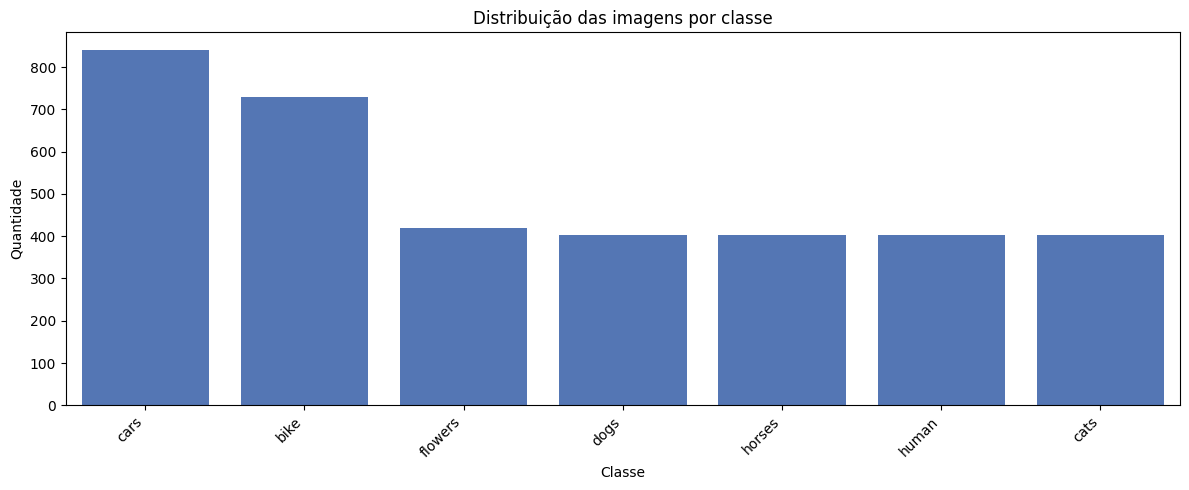

In [6]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='class_name', order=df['class_name'].value_counts().index, color='#4472C4')
plt.title('Distribuição das imagens por classe')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Visualização inicial

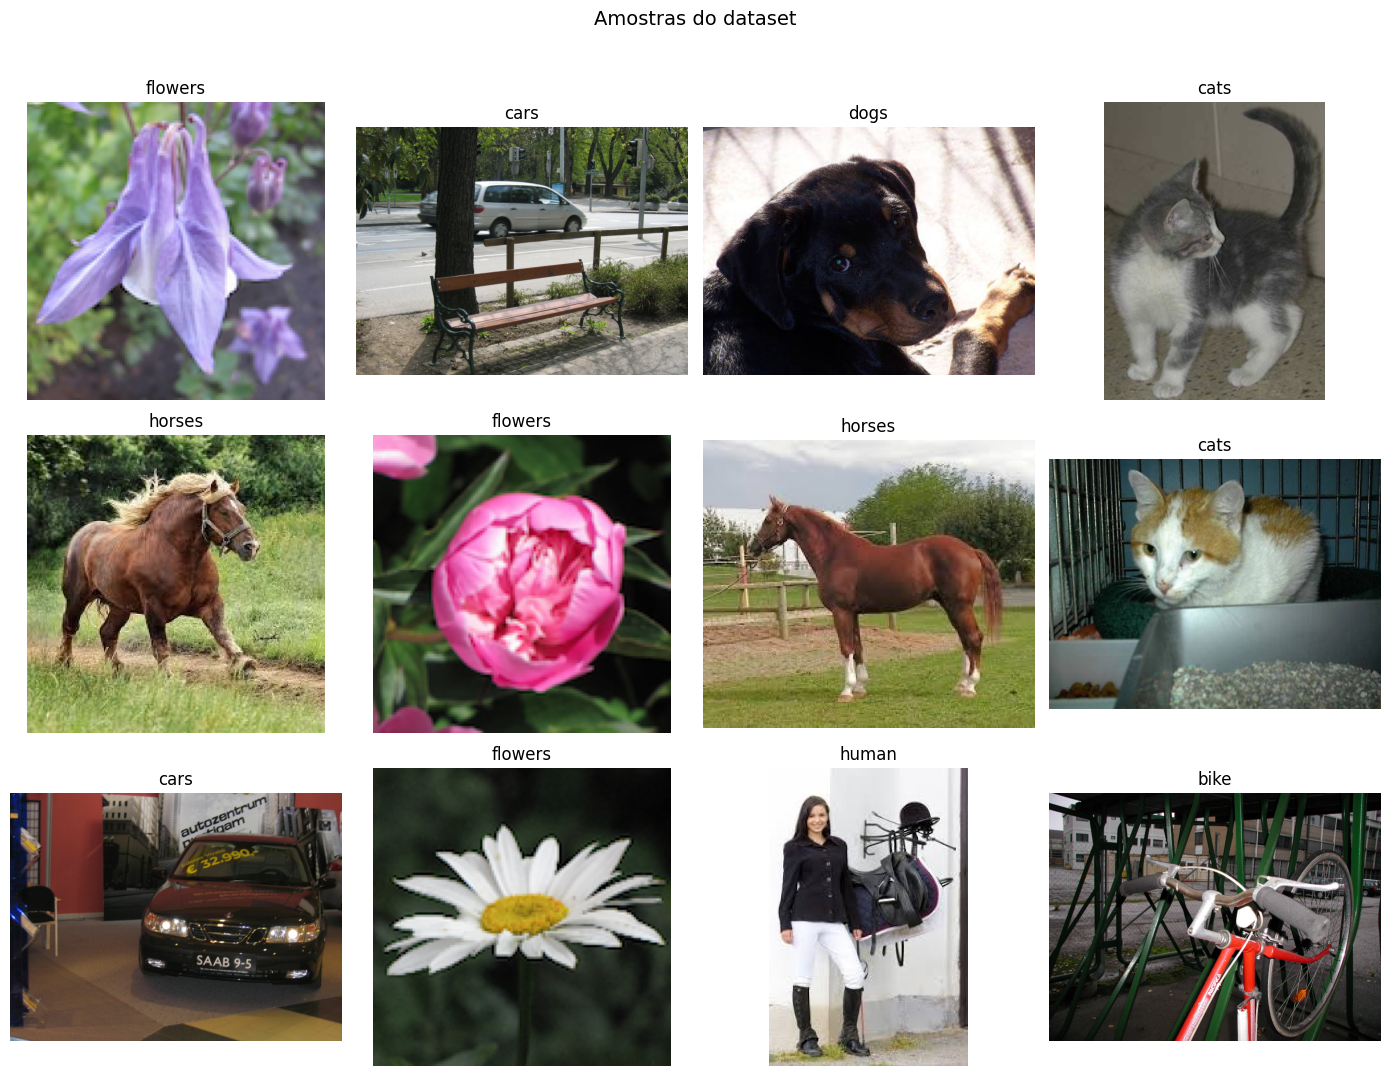

In [7]:
n_examples = min(12, len(df))
example_df = df.sample(n=n_examples, random_state=SEED)
n_cols = 4
n_rows = int(np.ceil(n_examples / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
axes = np.atleast_1d(axes).ravel()
for ax, (_, row) in zip(axes, example_df.iterrows()):
    image = Image.open(row['image_path']).convert('RGB')
    ax.imshow(image)
    ax.set_title(row['class_name'])
    ax.axis('off')
for ax in axes[n_examples:]:
    ax.axis('off')
plt.suptitle('Amostras do dataset', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 4. Divisão estratificada treino/validação

A divisão é de 80% para treinamento e 20% para validação. A estratificação preserva, na medida do possível, a proporção das classes.

In [8]:
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df['label'],
    random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

def distribution_table(frame, split_name):
    counts = frame['class_name'].value_counts().reindex(class_names, fill_value=0)
    return pd.DataFrame({'split': split_name, 'count': counts.values}, index=counts.index)

split_distribution = pd.concat([
    distribution_table(df, 'total'),
    distribution_table(train_df, 'train'),
    distribution_table(val_df, 'validation')
])
display(split_distribution.reset_index(names='class_name').pivot(index='class_name', columns='split', values='count'))
print(f'Train: {len(train_df)} imagens | Validation: {len(val_df)} imagens')

split,total,train,validation
class_name,,,
bike,730,584,146
cars,840,672,168
cats,404,323,81
dogs,404,323,81
flowers,420,336,84
horses,404,323,81
human,404,323,81


Train: 2884 imagens | Validation: 722 imagens


## 5. Preprocessing e DataLoaders

O baseline usa somente `Resize`, `CenterCrop`, `ToTensor` e a normalização do ImageNet. Não há augmentation. A normalização é necessária para manter a distribuição de entrada compatível com aquela utilizada no pré-treinamento da ResNet-50.

In [17]:
weights = ResNet50_Weights.DEFAULT
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

baseline_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

class ImageClassificationDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        label = torch.tensor(int(row['label']), dtype=torch.long)
        return image, label

train_dataset = ImageClassificationDataset(train_df, transform=baseline_transform)
val_dataset = ImageClassificationDataset(val_df, transform=baseline_transform)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)
pin_memory = torch.cuda.is_available()
# Mantém os workers vivos entre épocas; evita o 'AssertionError: can only test a child process'
# no Colab (Python 3.12), causado pelo descarte dos iteradores multiprocessados a cada época.
persistent_workers = NUM_WORKERS > 0
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory, generator=loader_generator, persistent_workers=persistent_workers)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory, persistent_workers=persistent_workers)
print(f'Train batches: {len(train_loader)} | Validation batches: {len(val_loader)} | pin_memory: {pin_memory}')

Train batches: 91 | Validation batches: 23 | pin_memory: True


## 6. ResNet-50 e feature extraction

O backbone recebe pesos do ImageNet e é congelado antes do treinamento. Depois, a cabeça original é substituída por uma camada linear com o número de classes do dataset.

In [18]:
model = resnet50(weights=weights)
for parameter in model.parameters():
    parameter.requires_grad = False

num_classes = len(class_names)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, num_classes)
model = model.to(DEVICE)

total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
frozen_parameters = total_parameters - trainable_parameters
print(f'Total parameters: {total_parameters:,}')
print(f'Trainable parameters: {trainable_parameters:,}')
print(f'Frozen parameters: {frozen_parameters:,}')
print(f'Trainable parameter tensors: {[name for name, p in model.named_parameters() if p.requires_grad]}')
assert all(p.requires_grad for p in model.fc.parameters())
assert all(not p.requires_grad for name, p in model.named_parameters() if not name.startswith('fc.'))

Total parameters: 23,522,375
Trainable parameters: 14,343
Frozen parameters: 23,508,032
Trainable parameter tensors: ['fc.weight', 'fc.bias']


## 7. Treinamento

A função de custo é cross-entropy e o otimizador atualiza somente os parâmetros de `model.fc`. O melhor estado segundo a acurácia de validação é salvo para a avaliação final.

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

history = {
    'train_loss': [], 'val_loss': [],
    'train_accuracy': [], 'val_accuracy': []
}
best_val_accuracy = -np.inf
best_state_dict = None

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss_sum = 0.0
    train_predictions, train_targets = [], []

    train_progress = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{NUM_EPOCHS} - train', leave=False)
    for images, labels in train_progress:
        images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        train_predictions.extend(logits.argmax(dim=1).detach().cpu().numpy())
        train_targets.extend(labels.detach().cpu().numpy())

    model.eval()
    val_loss_sum = 0.0
    val_predictions, val_targets = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            logits = model(images)
            loss = criterion(logits, labels)
            val_loss_sum += loss.item() * images.size(0)
            val_predictions.extend(logits.argmax(dim=1).cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    train_loss = train_loss_sum / len(train_dataset)
    val_loss = val_loss_sum / len(val_dataset)
    train_accuracy = accuracy_score(train_targets, train_predictions)
    val_accuracy = accuracy_score(val_targets, val_predictions)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_accuracy'].append(train_accuracy)
    history['val_accuracy'].append(val_accuracy)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_state_dict = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    print(f'Epoch {epoch + 1:02d}/{NUM_EPOCHS} | train loss: {train_loss:.4f} | train acc: {train_accuracy:.4f} | val loss: {val_loss:.4f} | val acc: {val_accuracy:.4f}')

model.load_state_dict(best_state_dict)
print(f'Best validation accuracy: {best_val_accuracy:.4f}')

Epoch 1/10 - train:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 01/10 | train loss: 0.4452 | train acc: 0.9286 | val loss: 0.1321 | val acc: 0.9889


Epoch 2/10 - train:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 02/10 | train loss: 0.0755 | train acc: 0.9927 | val loss: 0.0715 | val acc: 0.9931


Epoch 3/10 - train:   0%|          | 0/91 [00:00<?, ?it/s]

...

Epoch 08/10 | train loss: 0.0117 | train acc: 0.9993 | val loss: 0.0173 | val acc: 0.9958


Epoch 9/10 - train:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 09/10 | train loss: 0.0128 | train acc: 0.9983 | val loss: 0.0153 | val acc: 0.9972


Epoch 10/10 - train:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 10/10 | train loss: 0.0099 | train acc: 0.9990 | val loss: 0.0134 | val acc: 1.0000
Best validation accuracy: 1.0000


## 8. Curvas de loss e accuracy

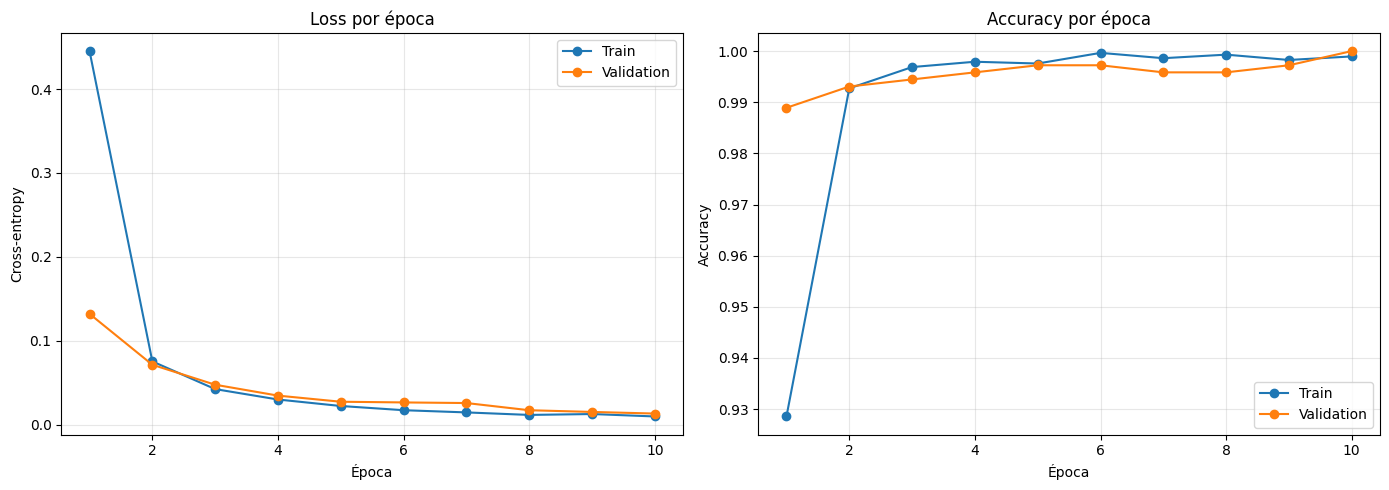

In [20]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history['train_loss'], marker='o', label='Train')
axes[0].plot(epochs, history['val_loss'], marker='o', label='Validation')
axes[0].set_title('Loss por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Cross-entropy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_accuracy'], marker='o', label='Train')
axes[1].plot(epochs, history['val_accuracy'], marker='o', label='Validation')
axes[1].set_title('Accuracy por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Avaliação final

A avaliação usa o melhor checkpoint de validação. São reportadas a accuracy global, a accuracy por classe e a matriz de confusão.

In [21]:
model.eval()
all_predictions, all_targets, all_paths = [], [], []
with torch.no_grad():
    for batch_index, (images, labels) in enumerate(val_loader):
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        predictions = logits.argmax(dim=1).cpu().numpy()
        start = batch_index * BATCH_SIZE
        end = start + len(labels)
        all_predictions.extend(predictions)
        all_targets.extend(labels.numpy())
        all_paths.extend(val_df.iloc[start:end]['image_path'].tolist())

global_accuracy = accuracy_score(all_targets, all_predictions)
print(f'Accuracy global: {global_accuracy:.4f} ({global_accuracy * 100:.2f}%)')

report = classification_report(
    all_targets, all_predictions, labels=list(range(num_classes)),
    target_names=class_names, zero_division=0, output_dict=True
)
per_class_accuracy = pd.DataFrame({
    'class_name': class_names,
    'accuracy': [report[name]['recall'] for name in class_names],
    'support': [report[name]['support'] for name in class_names]
})
display(per_class_accuracy)
print(classification_report(all_targets, all_predictions, labels=list(range(num_classes)), target_names=class_names, zero_division=0))

Accuracy global: 1.0000 (100.00%)


,class_name,accuracy,support
0,bike,1.0,146.0
1,cars,1.0,168.0
2,cats,1.0,81.0
3,dogs,1.0,81.0
4,flowers,1.0,84.0
5,horses,1.0,81.0
6,human,1.0,81.0


              precision    recall  f1-score   support

        bike       1.00      1.00      1.00       146
        cars       1.00      1.00      1.00       168
        cats       1.00      1.00      1.00        81
        dogs       1.00      1.00      1.00        81
     flowers       1.00      1.00      1.00        84
      horses       1.00      1.00      1.00        81
       human       1.00      1.00      1.00        81

    accuracy                           1.00       722
   macro avg       1.00      1.00      1.00       722
weighted avg       1.00      1.00      1.00       722



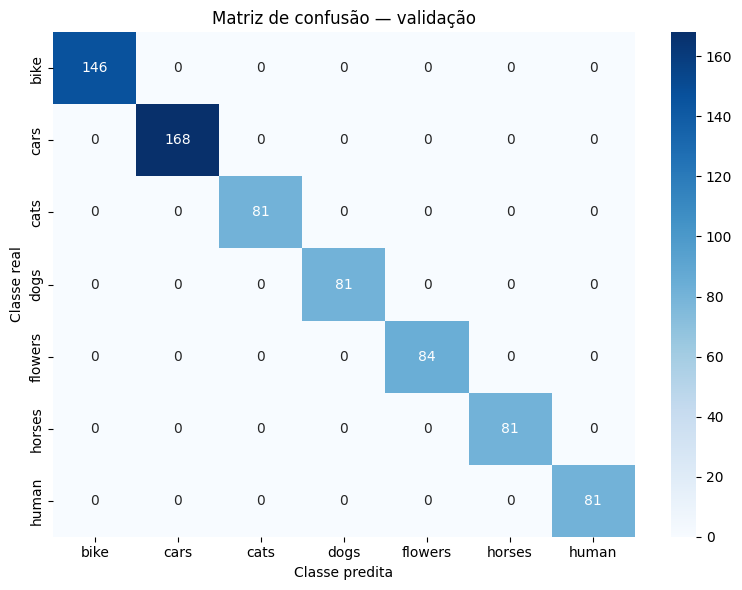

In [22]:
cm = confusion_matrix(all_targets, all_predictions, labels=list(range(num_classes)))
plt.figure(figsize=(max(8, len(class_names) * 0.7), max(6, len(class_names) * 0.6)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de confusão — validação')
plt.xlabel('Classe predita')
plt.ylabel('Classe real')
plt.tight_layout()
plt.show()

## 10. Exemplos de classificações incorretas

In [23]:
misclassified = pd.DataFrame({
    'image_path': all_paths,
    'true_label': all_targets,
    'pred_label': all_predictions
})
misclassified = misclassified[misclassified['true_label'] != misclassified['pred_label']].copy()
n_errors = min(12, len(misclassified))
print(f'Classificações incorretas: {len(misclassified)} de {len(val_df)}')

if n_errors == 0:
    print('Nenhuma classificação incorreta na validação.')
else:
    error_sample = misclassified.sample(n=n_errors, random_state=SEED)
    n_cols = 4
    n_rows = int(np.ceil(n_errors / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.8 * n_rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, error_sample.iterrows()):
        ax.imshow(Image.open(row['image_path']).convert('RGB'))
        ax.set_title(f'Real: {class_names[row.true_label]}\nPredita: {class_names[row.pred_label]}', color='crimson')
        ax.axis('off')
    for ax in axes[n_errors:]:
        ax.axis('off')
    plt.suptitle('Exemplos de erros do baseline', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

Classificações incorretas: 0 de 722
Nenhuma classificação incorreta na validação.


## 11. Análise e propostas de melhoria

As propostas abaixo são hipóteses para experimentos posteriores. Elas não fazem parte do experimento principal, que permanece como feature extraction sem augmentation. A escolha final deve ser confirmada por uma nova validação estratificada e, idealmente, por mais de uma seed.

| Técnica | Possível benefício | Riscos | Relação com o dataset | Próximo experimento? |
|---|---|---|---|---|
| **Geometric augmentation** (`RandomHorizontalFlip`, pequenas rotações e crops) | Aumenta a variedade de posições e reduz overfitting em um conjunto relativamente pequeno. | Flip ou rotação podem mudar a semântica de objetos orientados; crops agressivos podem remover partes importantes. | É adequada se as categorias forem invariantes a posição/orientação e se as imagens apresentarem enquadramentos variados. Deve ser moderada para objetos com orientação relevante. | **Sim**, começando por flip horizontal e rotações pequenas. |
| **Color augmentation** (pequenas mudanças de brilho, contraste e saturação) | Melhora a robustez a iluminação, câmera e fundo. | Pode apagar pistas de cor que distinguem categorias ou gerar cores irreais. | Faz sentido se as imagens tiverem iluminação variável e se a classe não depender principalmente da cor. | **Sim**, com `ColorJitter` conservador. |
| **Scale variation** (`RandomResizedCrop` com escala moderada) | Ajuda o modelo a reconhecer o objeto em diferentes tamanhos e distâncias. | Pode cortar o objeto ou alterar excessivamente a composição; objetos pequenos podem perder detalhes após o resize. | É promissora se houver variação de distância/enquadramento, mas deve preservar o objeto inteiro quando possível. | **Sim**, testando faixa de escala moderada e comparando a matriz de confusão. |
| **Normalização ImageNet** | Alinha a entrada à distribuição usada no pré-treinamento e facilita o reaproveitamento das features. | Se aplicada com valores errados, cria um deslocamento de distribuição; não é uma forma de augmentation. | É especialmente importante neste baseline com ResNet-50 ImageNet. | **Já utilizada**; deve permanecer em todos os experimentos com este backbone. |

### Interpretação do baseline

Compare a diferença entre as curvas de treino e validação, as classes com menor recall e os grupos mais confundidos na matriz de confusão. Um gap grande entre treino e validação sugere overfitting e torna augmentation uma candidata forte. Confusões entre classes visualmente semelhantes podem exigir variação geométrica/escala; confusões associadas à iluminação ou ao fundo podem se beneficiar de augmentation de cor. Como o backbone permanece congelado, estas melhorias atuam apenas na diversidade dos exemplos vistos pela cabeça treinável e não substituem um eventual fine-tuning, que está fora do escopo desta atividade.

## Conclusão

O experimento principal é um classificador supervisionado baseado em feature extraction: ResNet-50 com pesos ImageNet congelados e uma única classification head treinável. Registre os valores impressos de accuracy global, accuracy por classe, curvas, matriz de confusão e erros para compor a análise final da atividade.